In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [76]:
df = pd.read_csv("C:/Desktop/Master_XY/customer-churn-prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [77]:
# strip whitespace from all column names
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.duplicated()]

In [78]:
# to check data type of columns
df.info()          

# to calculate number of values that are null in the table
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [79]:
# converted a column to int and tried a relation if all total charges are null when tenure was 0 or not
df[
    (pd.to_numeric(df['TotalCharges'], errors='coerce').isnull())
    &
    (df['tenure'] == 0)
]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [80]:
# replaced the NaN values with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce').fillna(0)

In [81]:
# founded the indices which have tenure =0 to see that there total charges are empty or not
(
df[df['tenure'] == 0].index,
df.iloc[488]
)

(Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64'),
 customerID                         4472-LVYGI
 gender                                 Female
 SeniorCitizen                               0
 Partner                                   Yes
 Dependents                                Yes
 tenure                                      0
 PhoneService                               No
 MultipleLines                No phone service
 InternetService                           DSL
 OnlineSecurity                            Yes
 OnlineBackup                               No
 DeviceProtection                          Yes
 TechSupport                               Yes
 StreamingTV                               Yes
 StreamingMovies                            No
 Contract                             Two year
 PaperlessBilling                          Yes
 PaymentMethod       Bank transfer (automatic)
 MonthlyCharges                          52.55
 TotalCharges      

In [82]:
# here we confirmed that our column converted to float64 or not from that str
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [83]:
# checks repeated rows
df.duplicated().sum()

np.int64(0)

In [84]:
"""
(

df["gender"].unique(),

df.nunique()
)
"""

'\n(\n\ndf["gender"].unique(),\n\ndf.nunique()\n)\n'

In [85]:
"""
df["DeviceProtection"].unique()
df["OnlineBackup"].unique()
df["InternetService"].unique()
df["SeniorCitizen"].unique()
df["tenure"].unique()
"""

'\ndf["DeviceProtection"].unique()\ndf["OnlineBackup"].unique()\ndf["InternetService"].unique()\ndf["SeniorCitizen"].unique()\ndf["tenure"].unique()\n'

In [86]:
# my obs: mean < median means graph is left skewed
(
df["MonthlyCharges"].min(),
df["MonthlyCharges"].max(),
df["MonthlyCharges"].mean(),
df["MonthlyCharges"].median()
)

(np.float64(18.25),
 np.float64(118.75),
 np.float64(64.76169246059918),
 np.float64(70.35))

In [87]:
# my obs: mean > median means graph is right skewed
(
df["TotalCharges"].min(),
df["TotalCharges"].max(),
df["TotalCharges"].mean(),
df["TotalCharges"].median()
)

(np.float64(0.0),
 np.float64(8684.8),
 np.float64(2279.7343035638223),
 np.float64(1394.55))

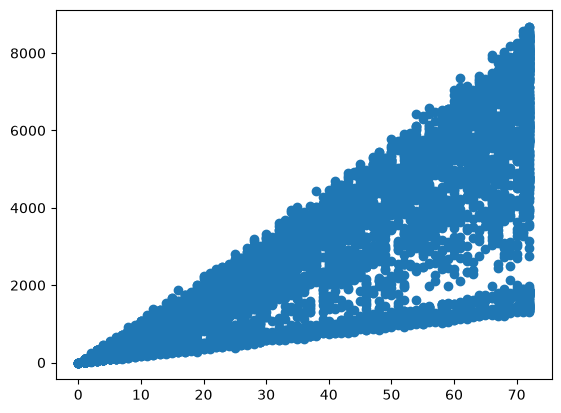

In [88]:
plt.scatter(df["tenure"], df["TotalCharges"])

In [89]:
monthly_tenure = df[df["Contract"] == "Month-to-month"]["tenure"]
one_year_tenure =  df[df["Contract"] == "One year"]["tenure"]
two_year_tenure =  df[df["Contract"] == "Two year"]["tenure"]


{'whiskers': [<matplotlib.lines.Line2D at 0x21569667d90>,
 'caps': [<matplotlib.lines.Line2D at 0x2156e0cc050>,
 'boxes': [<matplotlib.lines.Line2D at 0x21569667c50>,
 'medians': [<matplotlib.lines.Line2D at 0x2156e0cc2d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x2156e0cc410>,
 'means': []}

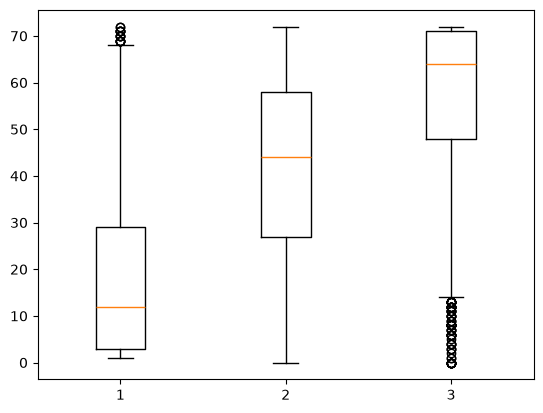

In [90]:
plt.boxplot([monthly_tenure, one_year_tenure, two_year_tenure])

In [91]:

(
df["Churn"].value_counts(),
df[df["Contract"] == "Month-to-month"]["Churn"].value_counts(),
df[df["Contract"] == "One year"]["Churn"].value_counts(),
df[df["Contract"] == "Two year"]["Churn"].value_counts(),
df[df["Contract"] == "Month-to-month"].shape[0]
)

(Churn
 No     5174
 Yes    1869
 Name: count, dtype: int64,
 Churn
 No     2220
 Yes    1655
 Name: count, dtype: int64,
 Churn
 No     1307
 Yes     166
 Name: count, dtype: int64,
 Churn
 No     1647
 Yes      48
 Name: count, dtype: int64,
 3875)

In [92]:
(
(df[df["Contract"] == "Month-to-month"]["Churn"].value_counts() * 100) / df[df["Contract"] == "Month-to-month"].shape[0],
(df[df["Contract"] == "One year"]["Churn"].value_counts() * 100) / df[df["Contract"] == "One year"].shape[0],
(df[df["Contract"] == "Two year"]["Churn"].value_counts() * 100) / df[df["Contract"] == "Two year"].shape[0]
)

(Churn
 No     57.290323
 Yes    42.709677
 Name: count, dtype: float64,
 Churn
 No     88.730482
 Yes    11.269518
 Name: count, dtype: float64,
 Churn
 No     97.168142
 Yes     2.831858
 Name: count, dtype: float64)

In [93]:
# x for input features and y for target
x = df.copy()
y = df["Churn"]


In [94]:
x= x.drop(columns=["customerID", "Churn"])
categorical_cols = x.select_dtypes(include="object").columns


C:\Users\maste\AppData\Local\Temp\ipykernel_6876\3966397002.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include="object").columns


In [95]:
# conversion tool
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

In [96]:
# to learn categorical cols
encoder.fit(x[categorical_cols])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreq

In [97]:
# actual transformed data, stored as sparse matrix
encoded = encoder.transform(x[categorical_cols])

In [98]:
# converted sparse matrix to data frame of pandas
encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=encoder.get_feature_names_out(categorical_cols)
)

In [99]:
encoded_df.shape

(7043, 26)

In [100]:
x = pd.concat(
    [x.select_dtypes(exclude=["object"]), encoded_df],
    axis= 1 
)

In [101]:
x.shape

(7043, 30)

In [102]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [103]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [104]:
scaler = StandardScaler()

In [105]:
x_train[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.fit_transform(
    x_train[["tenure", "MonthlyCharges", "TotalCharges"]]
)

In [106]:
x_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,-0.262257,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,0,-0.711743,0.337478,-0.503635,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,0,-0.793155,-0.809013,-0.749883,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3867,0,-0.263980,0.284384,-0.172722,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3810,0,-1.281624,-0.676279,-0.989374,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [107]:
x_test[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.transform(
    x_test[["tenure", "MonthlyCharges", "TotalCharges"]]
)

In [108]:
x_train[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


In [109]:
x_test[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,1409.000000,1409.000000,1409.000000
mean,-0.023184,-0.027911,-0.042990
std,0.998342,0.992131,0.972154
min,-1.322329,-1.549006,-1.008922
25%,-0.996684,-0.986545,-0.850914
50%,-0.182569,0.166583,-0.397009
75%,0.916486,0.813661,0.534693
max,1.608483,1.721231,2.719333


In [110]:
model = LogisticRegression()

In [111]:
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [112]:
predictions = model.predict(x_test)

In [113]:
accuracy = accuracy_score(y_test, predictions)

In [114]:
accuracy

0.8062455642299503

In [115]:
y_test.value_counts()

Churn
0    1035
1     374
Name: count, dtype: int64

In [116]:
np.unique(predictions, return_counts=True)

(array([0, 1]), array([1092,  317]))

In [117]:
np.unique(y_test, return_counts=True)

(array([0, 1]), array([1035,  374]))

In [118]:
np.unique(y_train, return_counts=True)

(array([0, 1]), array([4139, 1495]))

In [119]:
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.6593059936908517
Recall: 0.5588235294117647
F1-score: 0.6049204052098408


In [120]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[927 108]
 [165 209]]


In [121]:
model = LogisticRegression(class_weight="balanced")
model.fit(x_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the fol

In [122]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[927 108]
 [165 209]]


In [123]:
model.get_params()["class_weight"]

'balanced'

In [124]:
np.unique(predictions, return_counts=True)

(array([0, 1]), array([1092,  317]))

In [125]:
probabilities = model.predict_proba(x_test)

In [126]:
probabilities[:5]

array([[0.88250504, 0.11749496],
       [0.14849427, 0.85150573],
       [0.85073496, 0.14926504],
       [0.34166998, 0.65833002],
       [0.93960403, 0.06039597]])

In [127]:
churn_probabilities = probabilities[:, 1]

In [128]:
churn_probabilities[:10]

array([0.11749496, 0.85150573, 0.14926504, 0.65833002, 0.06039597,
       0.80463413, 0.69590129, 0.28938075, 0.00905399, 0.65278372])

In [129]:
threshold = 0.4

predictions_04 = (churn_probabilities >= threshold).astype(int)

In [130]:
confusion_matrix(y_test, predictions_04)

array([[664, 371],
       [ 50, 324]])

In [131]:
(
accuracy_score(y_test, predictions_04),
precision_score(y_test, predictions_04),
recall_score(y_test, predictions_04),
f1_score(y_test, predictions_04)
)

(0.7012065294535131,
 0.46618705035971225,
 0.8663101604278075,
 0.6061739943872778)

In [132]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

In [133]:
tree_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [134]:
tree_predictions = tree_model.predict(x_test)

In [135]:
tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Accuracy:", tree_accuracy)

Accuracy: 0.7253371185237757


In [136]:
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)

print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1 Score:", tree_f1)

Precision: 0.48247978436657685
Recall: 0.4786096256684492
F1 Score: 0.48053691275167787


In [137]:
tree_cm = confusion_matrix(y_test, tree_predictions)

print(tree_cm)

[[843 192]
 [195 179]]


In [138]:
print("Decision Tree Results")
print("--------------------")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)
print("\nConfusion Matrix:")
print(tree_cm)

Decision Tree Results
--------------------
Accuracy : 0.7253371185237757
Precision: 0.48247978436657685
Recall   : 0.4786096256684492
F1 Score : 0.48053691275167787

Confusion Matrix:
[[843 192]
 [195 179]]
